# Lab 1 : Intro Deep Learning avec Pytorch
## Polytech Paris-Saclay : Machine Learning II
### Name : Marko BABIC


## Exercise 0: Library loading and installation

In [ ]:
%matplotlib inline # Config pour forcer les graphiques à s'afficher en dessous de la cellule de code qui les a produits
!pip install numpy
!pip install torch
!pip install scikit-learn

## Exercise 1: Digits Prediction

In this exercise we will train a simple logistic regression model to classify the digits in the
digits dataset, a simplified version of the mnist dataset provided by scikit-learn. It consists of
black-and-white images of hand-drawn digits (between 0 and 9)

### Exercise 1.1: Data Loading and Visualization
 Download dataframe from scikit-learn

In [ ]:
from sklearn.datasets import load_digits# Import specific function to load the datasets of digits
import numpy as np
import torch

# return_X_y=True: Automatically separates the data into 'x' (features/images) and 'y' (labels/targets).
# as_frame=True: Loads the data as a Pandas DataFrame/Series instead of a raw Numpy array
x, y = load_digits(return_X_y=True, as_frame=True) # load MNIST dataset

### Unpack the dimensions of the dataset
# x.shape returns a tuple (number_of_rows, number_of_columns).
# n_samples: Total number of images (rows).
# n_features: Number of pixels per image (columns, which is 64 for 8x8 flattened images)
n_samples, n_features = x.shape

### Calculate the number of distinct classes
# np.unique(y): Finds all unique labels in the target vector (e.g., 0, 1, ..., 9).
n_classes = len(np.unique(y))

print(f"Number of samples: {n_samples}, Number of features: {n_features}")
print(f"Labels range {y.min()} - {y.max()}, Number of classes: {n_classes}")

Number of samples: 1797, Number of features: 64
Labels range 0 - 9, Number of classes: 10


Visualize data

In [ ]:
print(x)
print(y)

      pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0           0.0        0.0        5.0       13.0        9.0        1.0   
1           0.0        0.0        0.0       12.0       13.0        5.0   
2           0.0        0.0        0.0        4.0       15.0       12.0   
3           0.0        0.0        7.0       15.0       13.0        1.0   
4           0.0        0.0        0.0        1.0       11.0        0.0   
...         ...        ...        ...        ...        ...        ...   
1792        0.0        0.0        4.0       10.0       13.0        6.0   
1793        0.0        0.0        6.0       16.0       13.0       11.0   
1794        0.0        0.0        1.0       11.0       15.0        1.0   
1795        0.0        0.0        2.0       10.0        7.0        0.0   
1796        0.0        0.0       10.0       14.0        8.0        1.0   

      pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
0           0.0        0.0      

.describe() : computes a summary of statistics for each column (feature) in that DataFrame. Since our dataset represents images, each column represents one specific pixel position (from pixel 0 to pixel 63).

In [ ]:
x.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


The table tells you that your data is clean (no missing values), but unscaled (0-16 range instead of 0-1), and contains some features (like pixel_0_0) that are statistically irrelevant for classification.


The pixels in the corners are surely the least discriminative, since they never change
within the dataset images (mean = 0, std = 0)
Each image is 8 x 8, and is being stored as a flattened row of length 64.

Let's take a look at
one; we need to reshape it to 2d first. Then we will use the imshow function from
matplotlib to visualize it.

(1797, 64)


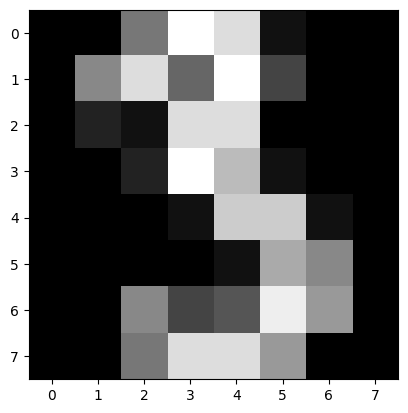

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

# iloc takes 1 line
# before we have a line of 64 pixels that represents an image
# so we put it in 2D : 8x8
plt.imshow(x.iloc[3].values.reshape((8, 8)), cmap="gray")
print(x.shape)

### Exercise 1.2: Data Preprocessing

We will use sklearn.model_selection.train_test_split which performs a stratified holdout cross-validation to create a single train test split with 90% - 10% of data in this case

In [ ]:
from sklearn.model_selection import train_test_split# for splitting data

# training and testing split
x_train, x_test, y_train, y_test = train_test_split(x.values, y.values, test_size=0.1,
stratify=y)


stratify = y


It forces the function to maintain the same proportion of classes in both the training and test sets as observed in the original dataset y.
Example: If 10% of your total images are the digit "5", then roughly 10% of your training set and 10% of your test set will be the digit "5".
Without this, a random split might accidentally put all the "5"s in the training set and none in the test set.


We always need to normalize the data with neural networks. The input data is stored with values in [0-16], we will normalize to [0-1].
$$ x = \frac{x - \min(x)}{\max(x)} $$

Without it the pixels goes from 0 to 16
Then we want a value beteween 0 and 1
* black pixel (0) become 0/16=0.0
* White pixel (16) become 16/16=1.0
* A certain gray pixel (8) become 8/16=0.5
* Another (12) become 12/16=0.75

We will use scikit-learn to do so, with the MinMaxScaler class. Remember to fit the scaler only on the training data, and then apply it to both the training and validation data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler # normalization tool

# This creates an empty "calculator" ready to learn the min and max values.
normalizer = MinMaxScaler()

### Fit AND Transform the training data ###
# - .fit(): Calculates the min (0) and max (16) from the 'x_train' data.
# - .transform(): Applies the formula (x - min) / (max - min) to scale 'x_train'.
# We ONLY fit on the training data to avoid "data leakage" (cheating by looking at test data statistics).
x_train = normalizer.fit_transform(x_train)

### Transform the test data ONLY ###
# We use the min/max values ALREADY LEARNED from 'x_train' to scale 'x_test'.
# We do NOT use .fit_transform() here, because the test set must remain "unseen" during the calibration.
x_test = normalizer.transform(x_test)

# The Test range should be very close to 0.0 - 1.0 (unless the test set has outliers outside the training range).
print(f"Train min: {x_train.min()}, max:{x_train.max()}")
print(f"Test min: {x_test.min()}, max:{x_test.max()}")

Train min: 0.0, max:1.0
Test min: 0.0, max:1.0


PyTorch uses torch.tensor , rather than numpy arrays, so we need to convert our data. Helps to keep the gradient and the tracks of the computation done on a vector.

In [ ]:
# Convert Feature Data (X) to PyTorch Tensors
# We use 'torch.as_tensor' to convert the Numpy arrays into PyTorch Tensors.
# dtype=torch.float32:
#   Neural networks operate using floating point math (matrix multiplication).
#   Since we normalized our pixels to be decimals (e.g., 0.5, 0.12), we MUST use floats.
#   We use 32-bit (float32) because it is the standard for GPUs and deep learning (faster than float64).
x_train = torch.as_tensor(x_train, dtype=torch.float32)
x_test = torch.as_tensor(x_test, dtype=torch.float32)

# Convert Label Data (Y) to PyTorch Tensors
# dtype=torch.long (64 bit integer):
#   We use integers here because 'y' represents distinct categories (Class 0, Class 1, ..., Class 9).
#   CRITICAL: PyTorch loss functions (like CrossEntropyLoss) expect labels to be integers (indices),
#   not floating point numbers. Passing floats here would cause an error later.
y_train = torch.as_tensor(y_train, dtype=torch.long)
y_test = torch.as_tensor(y_test, dtype=torch.long)

### Exercise 1.3: Neural networks from scratch (no torch.nn)

Let's first create a model using nothing but PyTorch tensor operations.
1. PyTorch provides methods to create random or zero-filled tensors, which we will use to
create our weights and bias for a simple linear model.
2. These are just regular tensors, with one very special addition: we tell PyTorch that they
require a gradient. This causes PyTorch to record all the operations done on the tensor.
3. This allows us and PyTorch to calculate the gradient during back-propagation
automatically !

#### The Model

We will use a very simple logistic regression with 10 output nodes (as many as the number of classes).
For the weights, we set requires_grad after the initialization, since we don't want that step included in the gradient.

1. We are initializing the weights here with the Xavier initialisation, by multiplying with $\frac{1}{\sqrt{n_{features}}}$

2. The trailing _ in PyTorch signifies that the operation is performed in-place
( requires_grad_() )

In [ ]:
### Initialize weights and bias ###

# We create a matrix of random numbers drawn from a standard normal distribution (mean=0, std=1).
# Dimensions: (64, 10) -> (n_features inputs, n_classes outputs).
weights = torch.randn(n_features, n_classes)
# Apply Xavier/Glorot Initialization
# We divide the random weights by the square root of the number of inputs (features).
# WHY? This keeps the signal from exploding (getting too big) or vanishing (getting too small)
# as it passes through layers. It ensures the variance of the output is similar to the input.
weights = weights / np.sqrt(n_features)

# Initialize Bias
# We create a vector of random numbers, one for each output class (10).
bias = torch.randn(n_classes)
# Scale Bias
# Similar to weights, we scale the bias (though often biases are just initialized to 0).
bias = bias / np.sqrt(n_features)

## tell pytorch it requires to compute the gradient ###

# Enable Gradient Tracking (The "Magic" Step)
# This tells PyTorch to watch these tensors and record EVERY math operation done on them.

# This is required so that PyTorch can automatically calculate the gradients (dL/dw)
# during backpropagation later.
# Note: The trailing underscore (_) means the operation is done "in-place" (modifies the variable directly).
weights.requires_grad_()
bias.requires_grad_()

tensor([-0.1447, -0.1370,  0.0496, -0.2220, -0.1046,  0.0243,  0.0115,  0.0204,
         0.0149, -0.0003], requires_grad=True)

Thanks to PyTorch's ability to calculate gradients automatically, we can use any standard Python function (or callable object) as a model!
Let's just write a plain matrix multiplication and broadcasted addition to create a simple linear model.

We also need an activation function, we'll use a log_softmax . Although PyTorch provides lots of pre-written loss functions, activation functions, and so forth, we can easily write our own using plain python.

PyTorch will even create fast GPU or vectorized CPU code for our function automatically.

In [ ]:
def model(xb):
  return log_softmax(xb @ weights + bias) # a @ b -> torch.matmul(a, b)
#@ for mat multiplication operation

def log_softmax(x):
  return x - x.exp().sum(-1).log().unsqueeze(-1) # => log(exp(x)/sum(exp(x_i)))

Let's now call our model function on one batch of data (in this case, 64 images). This is one forward pass.

Note: our predictions won't be any better than random at this stage, since we start with
random weights and we have not done any training step.

batch size is the number and size of input. Sometimes too big batch size makes big computations.

Example : You take a stack of 64 exams. You grade them, calculate the average error for that stack, update your guidelines, and move to the next stack of 64.

In [ ]:
### Define the Batch Size ###
# We decide to process 64 images at a time.
# This is a hyperparameter (a setting you choose).
bs = 64 # batch size

### Create a "Mini-Batch" of inputs (xb) ###
# We slice the training data 'x_train'.
# We take rows from index 0 up to (but not including) 64.
# Shape change: (1797, 64) -> (64, 64)
# (64 images, each having 64 pixels).
xb = x_train[0:bs] # a mini-batch from x

### Generate Predictions ###
# We pass this batch of 64 images into our function 'model'.
# The model performs the matrix multiplication: Input @ Weights + Bias.
# Shape change: (64, 64 inputs) @ (64 inputs, 10 outputs) -> (64, 10)
preds = model(xb) # predictions

### Inspect the results ###
# preds[0]: Shows the 10 scores for the VERY FIRST image in the batch.
# preds.shape: Confirms we have 64 rows (one per image) and 10 columns (one score per digit 0-9).
print(preds[0], preds.shape)

tensor([-2.4188, -2.7264, -2.8535, -2.4443, -1.7919, -2.1979, -2.1061, -2.5362,
        -1.8610, -2.7029], grad_fn=<SelectBackward0>) torch.Size([64, 10])


The preds tensor contains not only the tensor values, but also a gradient
function. We'll use this later to do the backpropagation

#### Loss and Metric

Let's implement negative log-likelihood to use as the loss function (again, we can just use standard Python).


Note that the way in which we have implemented it is just a clever way of doing the selection of the prediction corresponding to the correct label as in: ∑i yi ∗ log(fi).

If we check our loss with our random model now, we can see if we improve after a backprop pass later.

In [ ]:
##### Define the Negative Log Likelihood (NLL) Function #####
# This function calculates how "wrong" the model's predictions are.
# In classification, we want to maximize the probability of the correct class.
# Maximizing probability is mathematically the same as minimizing the negative log probability.
def nll(output, target):
    # 'output' shape: (batch_size, 10) -> The log-probabilities (or scores) for each class.
    # 'target' shape: (batch_size) -> The indices of the correct classes (e.g., [3, 0, 9...]).

    # We select the score predicted for the CORRECT class for each image.
    # Example: If image 0 is a "3", we grab output[0, 3].
    chosen_scores = output[range(target.shape[0]), target]

    # We take the negative mean of these scores.
    # If the model is good, the score for the correct class is high (e.g., 0).
    # If the model is bad, the score is low (e.g., -100).
    # Since we want to MINIMIZE loss, we flip the sign (-) so that bad scores become large positive numbers.
    return -chosen_scores.mean()

###### Assign the function to a variable #####
# This is common in PyTorch to make code modular (swapping loss functions easily).
loss_func = nll

##### Calculate Initial Loss #####
# model(x_train): Pass ALL training images through the network (Forward pass).
# loss_func(...): Compare the random initial predictions against the actual labels (y_train).
l = loss_func(model(x_train), y_train)

##### Print the result #####
# Since weights are random, the initial loss will be high/random.
# It serves as a baseline to see if training actually improves things later.
print(f"Initial Loss: {l}")

Initial Loss: 2.370502471923828


Let's also implement a function to calculate the accuracy of our model.
For each prediction, if the index with the largest value matches the target value, then the prediction was correct.
Let's check the accuracy of our random model, so we can see if our accuracy improves as our loss improves.

In [ ]:
def accuracy(out, yb):
  # 'out': The raw scores from the model (Batch_Size, 10).
  # 'yb': The correct labels (Batch_Size).



  # torch.argmax(..., dim=1): Looks at each row (dim=1) and finds the INDEX of the highest score.
  # Example: If scores are [0.1, 0.9, 0.0...], argmax returns index 1.
  # Result: A list of predicted digits, e.g., [1, 5, 9, 3...].
  preds = torch.argmax(out, dim=1)
  # (preds == yb): Creates a list of True/False values.
  # True if the prediction matches the label, False otherwise.
  # .float(): Converts True -> 1.0 and False -> 0.0.
  # .mean(): Calculates the average. (e.g., if 8 out of 10 are correct, mean is 0.8) then convert to percentage
  return (preds == yb).float().mean() * 100

acc = accuracy(model(x_train), y_train)
print(f"Initial Accuracy: {acc:.2f} %")

Initial Accuracy: 4.64 %


#### The training loop

We can now run a training loop. For each iteration, we will:
1. select a mini-batch of data (of size bs )
2. use the model to make predictions
3. calculate the loss
4. loss.backward() computes the gradients of the model, in this case, weights and bias .
5. update the parameters to optimize the model

In [ ]:
lr = .5 # learning rate
epochs = 20 # how many epochs to train for
train_samples = x_train.shape[0]

for epoch in range(epochs):
  for i in range((train_samples - 1) // bs + 1):

    ## select input and label batch
    start_i = i * bs
    end_i = start_i + bs
    xb = x_train[start_i:end_i]
    yb = y_train[start_i:end_i]

    ## make predictions and compute loss
    pred = model(xb)
    loss = loss_func(pred, yb)

    ## compute gradient through backprop
    loss.backward()

    ## update gradients through SGD
    with torch.no_grad():
      weights -= weights.grad * lr
      bias -= bias.grad * lr
      weights.grad.zero_()
      bias.grad.zero_()

  print(f"Epoch {epoch}: {loss_func(model(x_train), y_train):.2f}")

Epoch 0: 0.99
Epoch 1: 0.63
Epoch 2: 0.48
Epoch 3: 0.40
Epoch 4: 0.35
Epoch 5: 0.32
Epoch 6: 0.29
Epoch 7: 0.27
Epoch 8: 0.26
Epoch 9: 0.24
Epoch 10: 0.23
Epoch 11: 0.22
Epoch 12: 0.21
Epoch 13: 0.21
Epoch 14: 0.20
Epoch 15: 0.19
Epoch 16: 0.19
Epoch 17: 0.18
Epoch 18: 0.18
Epoch 19: 0.17


That's it: we've created and trained a minimal neural network (in this case, a logistic
regression, since we have no hidden layers) entirely from scratch!

Let's check the loss and accuracy and compare those to what we got earlier. We expect that
the loss will have decreased and accuracy to have increased, and they have.

In [ ]:
print(f"Loss after training: {loss_func(model(x_train), y_train):.2f}")
print(f"Accuracy after training: {accuracy(model(x_train), y_train):.2f}")

Loss after training: 0.17
Accuracy after training: 96.66


#### Let's refactor our code using torch.nn

We will now refactor our code, so that it does the same thing as before, only we'll start
taking advantage of PyTorch's nn classes to make it more concise and flexible.
At each step from here, we should be making our code one or more of:
1. shorter
2. more understandable
3. more flexible

### Exercise 1.4: Refactor using nn.functional

The first and easiest step is to make our code shorter by replacing our hand-written
activation and loss functions with those from torch.nn.functional (which is generally
imported into the namespace F by convention).

The torch.nn.functional module contains all the functions in the torch.nn library
.

As well as a wide range of loss and
activation functions, we'll also find here some convenient functions for creating deep neural networks, such as pooling functions.

If we're using negative log likelihood loss and log softmax activation, then Pytorch provides a single function F.cross_entropy that combines the two. So we can even remove the activation function from our model.

In [ ]:
import torch.nn.functional as F
loss_func = F.cross_entropy

def model(xb):
  return xb @ weights + bias
# @ for multiplaction of matrices

Note that we no longer call log_softmax in the model function. Let's confirm that our loss and accuracy are the same as before:

In [ ]:
print(f"Loss after refactoring: {loss_func(model(x_train), y_train)}")
print(f"Accuracy after refactoring: {accuracy(model(x_train), y_train)}")

Loss after refactoring: 0.17276133596897125
Accuracy after refactoring: 96.66048431396484


### Exercise 1.5: Refactor using nn.Module

Next up, we'll use nn.Module (uppercase M) and nn. Parameter , for a clearer and more
concise training loop.

1. We subclass nn.Module (which itself is a class and able to keep track of its attributes). In this case, we want to create a class that holds our weights, bias, and method for the forward step. nn.Module has a number of attributes and methods (such as .parameters() and .zero_grad() ) which we will be using for this.

2. Since we're now using an object instead of just using a function, we first have to
instantiate our model:

In [ ]:
from torch import nn
class LogisticRegression(nn.Module):
  def __init__ (self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(n_features, n_classes) / np.sqrt(n_features))
    self.bias = nn.Parameter(torch.randn(n_classes) / np.sqrt(n_features))

  def forward(self, xb):
    return xb @ self.weights + self.bias

model = LogisticRegression()

Now we can calculate the loss in the same way as before. Note that nn.Module objects are
used as if they are functions (i.e they are callable), but behind the scenes Pytorch will call our forward method automatically

In [ ]:
print(loss_func(model(x_train), y_train), accuracy(model(x_train), y_train))

tensor(2.2994, grad_fn=<NllLossBackward0>) tensor(16.1410)


Now we can take advantage of model.parameters() and model.zero_grad() to make those steps more concise and less prone to the error of forgetting some of our parameters,
particularly if we had a more complicated model:

We'll wrap our little training loop in a fit function so we can run it again later. And we
double-check that our loss has gone down:

In [ ]:
def fit():
  for epoch in range(epochs):
    for i in range((train_samples - 1) // bs + 1):
      start_i = i * bs
      end_i = start_i + bs
      xb = x_train[start_i:end_i]
      yb = y_train[start_i:end_i]
      pred = model(xb)
      loss = loss_func(pred, yb)
      loss.backward()

      with torch.no_grad():
        for p in model.parameters():
          p -= p.grad * lr
        model.zero_grad()
      print(f"Epoch: {epoch}, {loss_func(model(x_train), y_train):.2f}")

fit()
print(f"Accuracy: {accuracy(model(x_train), y_train):.2f}")

Epoch: 0, 2.22
Epoch: 0, 2.13
Epoch: 0, 2.04
Epoch: 0, 1.93
Epoch: 0, 1.85
Epoch: 0, 1.78
Epoch: 0, 1.71
Epoch: 0, 1.66
Epoch: 0, 1.59
Epoch: 0, 1.52
Epoch: 0, 1.47
Epoch: 0, 1.41
Epoch: 0, 1.37
Epoch: 0, 1.33
Epoch: 0, 1.30
Epoch: 0, 1.25
Epoch: 0, 1.21
Epoch: 0, 1.17
Epoch: 0, 1.13
Epoch: 0, 1.11
Epoch: 0, 1.07
Epoch: 0, 1.05
Epoch: 0, 1.01
Epoch: 0, 1.00
Epoch: 0, 0.98
Epoch: 0, 0.96
Epoch: 1, 0.92
Epoch: 1, 0.91
Epoch: 1, 0.90
Epoch: 1, 0.87
Epoch: 1, 0.84
Epoch: 1, 0.83
Epoch: 1, 0.81
Epoch: 1, 0.81
Epoch: 1, 0.79
Epoch: 1, 0.77
Epoch: 1, 0.76
Epoch: 1, 0.74
Epoch: 1, 0.74
Epoch: 1, 0.73
Epoch: 1, 0.72
Epoch: 1, 0.70
Epoch: 1, 0.69
Epoch: 1, 0.68
Epoch: 1, 0.67
Epoch: 1, 0.66
Epoch: 1, 0.65
Epoch: 1, 0.64
Epoch: 1, 0.63
Epoch: 1, 0.63
Epoch: 1, 0.62
Epoch: 1, 0.61
Epoch: 2, 0.60
Epoch: 2, 0.59
Epoch: 2, 0.59
Epoch: 2, 0.58
Epoch: 2, 0.57
Epoch: 2, 0.57
Epoch: 2, 0.56
Epoch: 2, 0.56
Epoch: 2, 0.55
Epoch: 2, 0.54
Epoch: 2, 0.54
Epoch: 2, 0.53
Epoch: 2, 0.53
Epoch: 2, 0.53
Epoch: 2, 

### Exercise 1.6: Refactor using nn.Linear

We continue to refactor our code. Instead of manually defining and initializing self.weights and self.bias , and calculating xb @ self.weights + self.bias , we will instead use the Pytorch class nn.Linear for a linear layer, which does all that for us.


Pytorch has many types of predefined layers that can greatly simplify our code, and often
makes it faster too!

In [ ]:
class LogisticRegression(nn.Module):
  def __init__(self):
    super().__init__()

    # self.lin = ... creates a layer and assigns it to the model.
    # nn.Linear(in_features, out_features) automatically creates the weights (W) and bias (b).
    # - n_features (64): The number of input pixels.
    # - n_classes (10): The number of output scores.
    # It replaces the manual 'weights = torch.randn(...)' we did earlier.
    self.lin = nn.Linear(n_features, n_classes)

  # This defines how data flows through the network when we our call 'model(data)'.
  # PyTorch automatically calls this function; we don't call .forward() ourself.
  def forward(self, xb):
    # xb: The input batch of images.
    # We pass the input 'xb' through the linear layer defined above.
    # It performs: Output = xb @ W + b
    return self.lin(xb)

We instantiate our model and calculate the loss in the same way as before:

In [ ]:
model = LogisticRegression()

In [ ]:
fit()
print(f"Loss: {loss_func(model(x_train), y_train)}, Accuracy: {accuracy(model(x_train),y_train)}")

Epoch: 0, 2.19
Epoch: 0, 2.11
Epoch: 0, 2.03
Epoch: 0, 1.93
Epoch: 0, 1.84
Epoch: 0, 1.77
Epoch: 0, 1.70
Epoch: 0, 1.65
Epoch: 0, 1.59
Epoch: 0, 1.52
Epoch: 0, 1.46
Epoch: 0, 1.41
Epoch: 0, 1.37
Epoch: 0, 1.33
Epoch: 0, 1.30
Epoch: 0, 1.26
Epoch: 0, 1.21
Epoch: 0, 1.17
Epoch: 0, 1.13
Epoch: 0, 1.11
Epoch: 0, 1.08
Epoch: 0, 1.05
Epoch: 0, 1.01
Epoch: 0, 1.00
Epoch: 0, 0.98
Epoch: 0, 0.97
Epoch: 1, 0.93
Epoch: 1, 0.91
Epoch: 1, 0.90
Epoch: 1, 0.87
Epoch: 1, 0.85
Epoch: 1, 0.83
Epoch: 1, 0.82
Epoch: 1, 0.81
Epoch: 1, 0.79
Epoch: 1, 0.77
Epoch: 1, 0.76
Epoch: 1, 0.75
Epoch: 1, 0.74
Epoch: 1, 0.73
Epoch: 1, 0.72
Epoch: 1, 0.71
Epoch: 1, 0.69
Epoch: 1, 0.68
Epoch: 1, 0.67
Epoch: 1, 0.66
Epoch: 1, 0.65
Epoch: 1, 0.65
Epoch: 1, 0.63
Epoch: 1, 0.63
Epoch: 1, 0.62
Epoch: 1, 0.62
Epoch: 2, 0.60
Epoch: 2, 0.59
Epoch: 2, 0.60
Epoch: 2, 0.58
Epoch: 2, 0.57
Epoch: 2, 0.57
Epoch: 2, 0.56
Epoch: 2, 0.56
Epoch: 2, 0.56
Epoch: 2, 0.55
Epoch: 2, 0.54
Epoch: 2, 0.53
Epoch: 2, 0.53
Epoch: 2, 0.53
Epoch: 2, 

#### Exercise 1.7: Refactor using optim

Pytorch also has a package with various optimization algorithms, torch.optim . To implement the previous stochastic gradient descent (SGD) optimization step, we can use
optim.SGD(params, lr) passing to it all the model parameters and the learning rate

We can use the step method from our optimizer to take a forward step, instead of manually updating each parameter.

optim.zero_grad() resets the gradient to 0 and we need to call it before computing the gradient for the next minibatch

In [ ]:
from torch import optim
model = LogisticRegression()

opt = optim.SGD(model.parameters(), lr=lr)
print(f"Accuracy: {accuracy(model(x_train), y_train)}")

def fit():
  for epoch in range(epochs):
    for i in range((train_samples - 1) // bs + 1):
      start_i = i * bs
      end_i = start_i + bs
      xb = x_train[start_i:end_i]
      yb = y_train[start_i:end_i]
      pred = model(xb)
      loss = loss_func(pred, yb)

Accuracy: 3.277674674987793


### Exercise 1.8: Refactor using Dataset

PyTorch has an abstract Dataset class in torch.utils.data.Dataset . A Dataset can be anything that has:

a getitem function as a way of indexing into it.



*   a \__len__ function (called by Python's standard len function)
*   a \__getitem__ function as a way of indexing into it



PyTorch's TensorDataset is a Dataset wrapping tensors. By defining a length and way of
indexing, this also gives us a way to iterate, index, and slice along the first dimension of a
tensor.

Both x_train and y_train can be combined in a single TensorDataset , which will be easier to iterate over and slice.

In [ ]:
from torch.utils.data import TensorDataset
train_ds = TensorDataset(x_train, y_train)

Previously, we had to iterate through minibatches of x and y values separately. Now, we can do these two steps together

In [ ]:
model = LogisticRegression()
opt = optim.SGD(model.parameters(), lr=lr)

print(f"Accuracy: {accuracy(model(x_train), y_train)}")

def fit():
  for epoch in range(epochs):
    for i in range((train_samples - 1) // bs + 1):
      xb, yb = train_ds[i * bs: i * bs + bs]# WHAT WE CHANGED
      pred = model(xb)
      loss = loss_func(pred, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    print(f"Epoch: {epoch}, {loss_func(model(x_train), y_train)}")

fit()
print(f"Accuracy: {accuracy(model(x_train), y_train)}")

Accuracy: 14.842300415039062
Epoch: 0, 0.9897251129150391
Epoch: 1, 0.6211763620376587
Epoch: 2, 0.476591557264328
Epoch: 3, 0.39933061599731445
Epoch: 4, 0.35043832659721375
Epoch: 5, 0.3162120580673218
Epoch: 6, 0.2906249463558197
Epoch: 7, 0.2705997824668884
Epoch: 8, 0.25439098477363586
Epoch: 9, 0.24092890322208405
Epoch: 10, 0.2295180857181549
Epoch: 11, 0.21968507766723633
Epoch: 12, 0.21109533309936523
Epoch: 13, 0.20350511372089386
Epoch: 14, 0.19673243165016174
Epoch: 15, 0.1906381994485855
Epoch: 16, 0.18511424958705902
Epoch: 17, 0.1800750494003296
Epoch: 18, 0.17545200884342194
Epoch: 19, 0.17118936777114868
Accuracy: 96.72232055664062


### Exercise 1.9: Refactor using DataLoader

Pytorch's **DataLoader** is responsible for managing batches. We can create a DataLoader from any  Dataset . DataLoader makes it easier to iterate over batches. Rather than
having to use train_ds[i*bs : i*bs+bs] , the DataLoader gives us each minibatch automatically.

Also Shuffling the training data is important to prevent correlation between batches and overfitting. DataLoader provides the parameter shuffle=True to do it.

For data intensive training (e.g. big images, or videos), it also allows to employ multiprocessing to load the data in parallel to the training loop with the parameter num_workers

In [ ]:
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

Previously, our loop iterated over batches (xb, yb) like this:
```
for i in range((n-1)//bs + 1):
  xb,yb = train_ds[i*bs : i*bs+bs]
  pred = model(xb)
```

Now, our loop is much cleaner, as (xb, yb) are loaded automatically from the data loader:



```
for xb,yb in train_dl:
  pred = model(xb)
```




In [ ]:
model = LogisticRegression()
opt = optim.SGD(model.parameters(), lr=lr)
print(f"Accuracy: {accuracy(model(x_train), y_train)}")

def fit():
  for epoch in range(epochs):
    for xb, yb in train_dl: # we don't have to specify anymore nor bs nor train
      pred = model(xb)
      loss = loss_func(pred, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()

    print(f"Epoch: {epoch}, {loss_func(model(x_train), y_train)}")

fit()
print(f"Accuracy: {accuracy(model(x_train), y_train)}")

Accuracy: 8.596165657043457
Epoch: 0, 0.9941684007644653
Epoch: 1, 0.6239739060401917
Epoch: 2, 0.4866074025630951
Epoch: 3, 0.4091748297214508
Epoch: 4, 0.35318830609321594
Epoch: 5, 0.31681251525878906
Epoch: 6, 0.2923652231693268
Epoch: 7, 0.27082520723342896
Epoch: 8, 0.25890257954597473
Epoch: 9, 0.23999591171741486
Epoch: 10, 0.22929613292217255
Epoch: 11, 0.2224160134792328
Epoch: 12, 0.21231487393379211
Epoch: 13, 0.20223446190357208
Epoch: 14, 0.197988823056221
Epoch: 15, 0.19122804701328278
Epoch: 16, 0.18562625348567963
Epoch: 17, 0.18062739074230194
Epoch: 18, 0.1772843450307846
Epoch: 19, 0.17010357975959778
Accuracy: 97.21707153320312


Thanks to Pytorch's nn.Module , nn.Parameter , Dataset , and DataLoader , our training loop is now dramatically smaller and easier to understand. Let's now try to add the basic features necessary to create effective models in practice.

### Exercise 1.10: Add validation

So far, we were just trying to get a reasonable training loop set up for use on our training data.
In reality, we always should also have a validation set, in order to identify if we are overfitting.

We will extract it from the training set and use it to evaluate the model at theend of each epoch.

We'll use a batch size for the test set that is twice as large as that for the training set. This is because the validation set does not need backpropagation and thus takes less memory (it doesn't need to store the gradients).

We take advantage of this to use a larger batch size and compute the loss more quickly by inserting the validation loop in a with torch.no_grad():

In [ ]:
### Validation Set (Splitting the Training Data)###
# 90% train, 10% validation
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

## Create the Training Dataset et Dataloader ##
# TensorDataset: Merges the features (x) and labels (y) into a single object.
# It allows us to access a sample by index: train_ds[0] returns (image_0, label_0).
train_ds = TensorDataset(x_train, y_train)

# DataLoader: This is an iterator that handles the "logistics" of feeding data to the model.
# - batch_size=bs: Cuts the data into stacks of 64 images.
# - shuffle=True: We shuffle the data before every epoch.
#   This ensures the model doesn't learn the order of the data and helps Gradient Descent converge.
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

# Create the Validation Dataset
valid_ds = TensorDataset(x_valid, y_valid)
# Create the Validation DataLoader
# batch_size=bs * 2: We double the batch size (e.g., 128 instead of 64).
# => Why? During validation, we don't store gradients (no backpropagation), so we use less memory.
# => We can afford to process more images at once to make the evaluation faster.
valid_dl = DataLoader(valid_ds, batch_size=bs * 2) # No need to shuffle the Validation


We will calculate and print the validation loss at the end of each epoch.

Note that we always call model.train() before training, and model.eval() before inference, because these are used by some layers (not employed here) such as nn.BatchNorm2d and nn.Dropout to ensure appropriate behaviour for these different
phases.

In [ ]:
model = LogisticRegression()
opt = optim.SGD(model.parameters(), lr=lr)

def fit():
  for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
      pred = model(xb)
      loss = loss_func(pred, yb)

      loss.backward()
      opt.step()
      opt.zero_grad()

    model.eval()
    with torch.no_grad():
      valid_losses, valid_accs = [], []
      for xb, yb in valid_dl:
        valid_losses.append(loss_func(model(xb), yb))
        valid_accs.append(accuracy(model(xb), yb))

    print(f"Epoch {epoch:.2f}: Val Loss {np.mean(valid_losses):.2f}, "f"Val Acc: {np.mean(valid_accs):.2f}")

fit()

Epoch 0.00: Val Loss 1.07, Val Acc: 87.57
Epoch 1.00: Val Loss 0.68, Val Acc: 89.82
Epoch 2.00: Val Loss 0.52, Val Acc: 91.38
Epoch 3.00: Val Loss 0.44, Val Acc: 91.77
Epoch 4.00: Val Loss 0.39, Val Acc: 93.64
Epoch 5.00: Val Loss 0.35, Val Acc: 93.24
Epoch 6.00: Val Loss 0.33, Val Acc: 94.72
Epoch 7.00: Val Loss 0.31, Val Acc: 94.32
Epoch 8.00: Val Loss 0.29, Val Acc: 95.11
Epoch 9.00: Val Loss 0.28, Val Acc: 93.64
Epoch 10.00: Val Loss 0.27, Val Acc: 93.24
Epoch 11.00: Val Loss 0.26, Val Acc: 93.24
Epoch 12.00: Val Loss 0.26, Val Acc: 94.32
Epoch 13.00: Val Loss 0.25, Val Acc: 93.24
Epoch 14.00: Val Loss 0.24, Val Acc: 93.24
Epoch 15.00: Val Loss 0.24, Val Acc: 94.72
Epoch 16.00: Val Loss 0.24, Val Acc: 95.11
Epoch 17.00: Val Loss 0.23, Val Acc: 95.11
Epoch 18.00: Val Loss 0.23, Val Acc: 94.72
Epoch 19.00: Val Loss 0.22, Val Acc: 96.58


### Exercise 1.11: Saving best model: early stopping

It may have happend that the model has reached the highest validation accuracy (and/or lower validation loss) not at the last epoch. It means that the model overfitted the training
data.


A possible way to avoid this phenomenon is to save the model achieving the best validation
accuracy (other possible solutions includes reducing the learning rate and decreasing the number of training epochs).


There exists two possible way to do it in pytorch. torch.save() and torch.load() can be used with any kind of objects. Torch will serialized this object through pickle. However, if
the code generating the object is modified the code might brake in several ways.

To avoid this issue, torch provides another couple of functions, model.state_dict() and
model.load_state_dict() , which only save and load the weights of the network.

```
torch.save(model.state_dict(), "./best_model.pt")
model.load_state_dict(torch.load("./best_model.pt"))
```

In [ ]:
model = LogisticRegression()
opt = optim.SGD(model.parameters(), lr=lr)

def fit():
  best_acc = 0.
  for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
      pred = model(xb)
      loss = loss_func(pred, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()

    model.eval()
    with torch.no_grad():
      valid_losses, valid_accs = [], []
      for xb, yb in valid_dl:
        valid_losses.append(loss_func(model(xb), yb))
        valid_accs.append(accuracy(model(xb), yb))

    if best_acc < np.mean(valid_accs):
      ## FOR SAVING THE MODEL ##
      torch.save(model.state_dict(), "./best_model.pt")
      best_acc = np.mean(valid_accs)

    print(f"Epoch {epoch}: Loss {np.mean(valid_losses):.2f}, \
Acc: {np.mean(valid_accs):.2f}")

  model.load_state_dict(torch.load("./best_model.pt"))
  model.eval()
  print(f"Best Valid Acc: {np.mean([accuracy(model(xb), yb) for xb, yb in valid_dl]):.2f}")

fit()

Epoch 0: Loss 1.03, Acc: 93.15
Epoch 1: Loss 0.68, Acc: 90.99
Epoch 2: Loss 0.54, Acc: 93.54
Epoch 3: Loss 0.45, Acc: 94.32
Epoch 4: Loss 0.39, Acc: 94.72
Epoch 5: Loss 0.36, Acc: 93.24
Epoch 6: Loss 0.34, Acc: 93.24
Epoch 7: Loss 0.32, Acc: 94.32
Epoch 8: Loss 0.30, Acc: 93.24
Epoch 9: Loss 0.29, Acc: 93.24
Epoch 10: Loss 0.28, Acc: 94.32
Epoch 11: Loss 0.27, Acc: 94.72
Epoch 12: Loss 0.26, Acc: 95.11
Epoch 13: Loss 0.25, Acc: 94.72
Epoch 14: Loss 0.25, Acc: 95.11
Epoch 15: Loss 0.24, Acc: 95.11
Epoch 16: Loss 0.24, Acc: 95.11
Epoch 17: Loss 0.24, Acc: 95.11
Epoch 18: Loss 0.23, Acc: 94.72
Epoch 19: Loss 0.23, Acc: 94.72
Best Valid Acc: 95.11


Finally, we test the model on the test set to see if it generalizes well also there. Note: There might be a discrepancy between the validation and test accuracy, but it should not be too
large.

In [ ]:
model = model.cpu()#we select cpu for testing
test_dl = DataLoader(TensorDataset(x_test, y_test), batch_size=bs * 2)
print(f"Test Acc: {np.mean([accuracy(model(xb), yb) for xb, yb in test_dl]):.2f}")

Test Acc: 96.69


### Exercice 1.12: Using the GPU

If we're lucky enough to have access to a CUDA-capable GPU we can use it to speed up your code.

In google COLAB we can change runtime type in the Runtime dropdown menu to enable GPU computation.
After changing the runtime type we will need to rerun the whole notebook beacause all variables will be
lost (Runtime -> Run all).

Let's check that our GPU is working with Pytorch. It should print True if everything is set up correctly

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
if torch.cuda.is_available():
    dev = torch.device("cuda")
    print("Cuda loaded")
else:
    dev = torch.device("cpu")
    print("CPU loaded")

Cuda loaded


Let's then create a device object for it:

In [ ]:
model = LogisticRegression().to(dev)
opt = optim.SGD(model.parameters(), lr=lr)

def fit():
  best_acc = 0.
  for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
      xb, yb = xb.to(dev), yb.to(dev)
      pred = model(xb)
      loss = loss_func(pred, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()

    model.eval()
    with torch.no_grad():
      valid_losses, valid_accs = [], []
      for xb, yb in valid_dl:

        xb, yb = xb.to(dev), yb.to(dev)
        valid_losses.append(loss_func(model(xb), yb).cpu())
        valid_accs.append(accuracy(model(xb), yb).cpu())

      if best_acc < np.mean(valid_accs):
        torch.save(model.state_dict(), "./best_model.pt")
        best_acc = np.mean(valid_accs)
    print(f"Epoch {epoch}: Loss {np.mean(valid_losses):.2f}, "f"Acc: {np.mean(valid_accs):.2f}")

  model.load_state_dict(torch.load("./best_model.pt"))
  model.eval()
  final_acc = np.mean([accuracy(model(xb.to(dev)), yb.to(dev)).item() for xb, yb in valid_dl])

fit()



Epoch 0: Loss 1.05, Acc: 85.62
Epoch 1: Loss 0.68, Acc: 90.60
Epoch 2: Loss 0.55, Acc: 91.68
Epoch 3: Loss 0.45, Acc: 92.85
Epoch 4: Loss 0.39, Acc: 93.64
Epoch 5: Loss 0.36, Acc: 93.24
Epoch 6: Loss 0.33, Acc: 93.64
Epoch 7: Loss 0.31, Acc: 93.24
Epoch 8: Loss 0.30, Acc: 94.72
Epoch 9: Loss 0.29, Acc: 93.64
Epoch 10: Loss 0.28, Acc: 93.24
Epoch 11: Loss 0.27, Acc: 93.64
Epoch 12: Loss 0.26, Acc: 94.72
Epoch 13: Loss 0.25, Acc: 95.11
Epoch 14: Loss 0.25, Acc: 93.64
Epoch 15: Loss 0.24, Acc: 94.72
Epoch 16: Loss 0.24, Acc: 95.11
Epoch 17: Loss 0.23, Acc: 95.11
Epoch 18: Loss 0.23, Acc: 95.11
Epoch 19: Loss 0.23, Acc: 94.72


It ran faster

## Exercise 2: What has the network learnt?

### Exercise 2.1: Weight visualization

So far we have seen that the network has learnt, but how can we visualize it? There exists several mechanism to do so.

Bias: tensor([-0.0675, -0.1043, -0.0213,  0.1766,  0.1028, -0.0565, -0.1538,  0.2048,
        -0.3313, -0.0487])


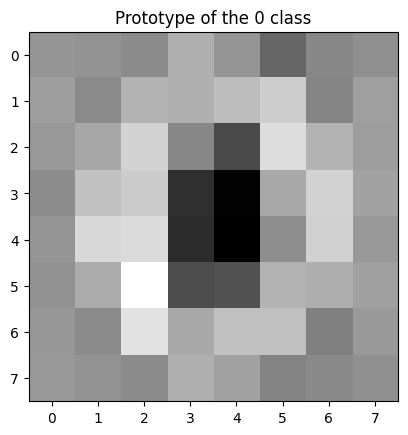

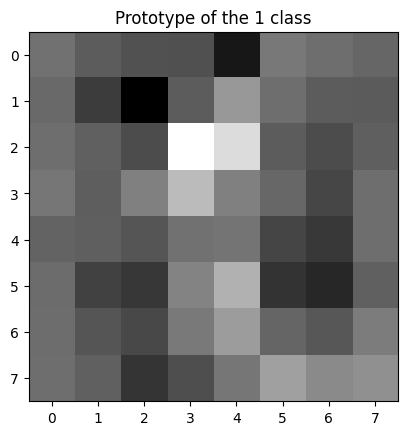

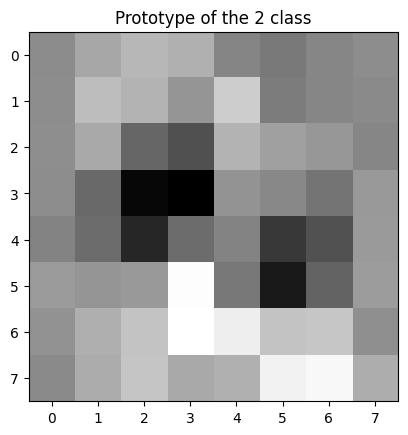

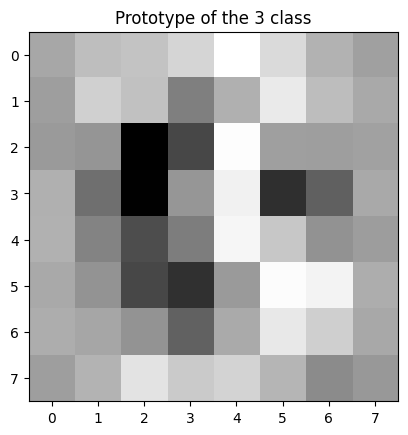

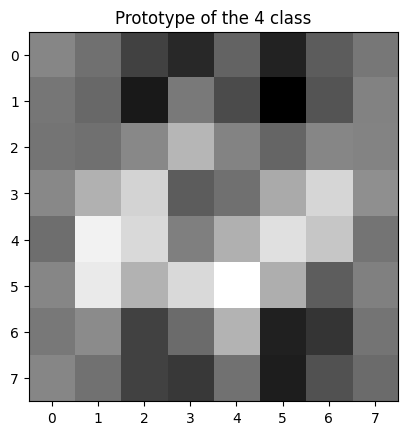

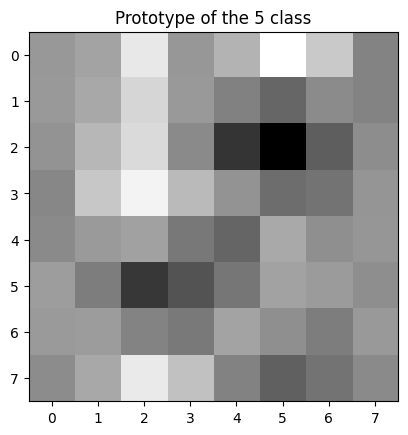

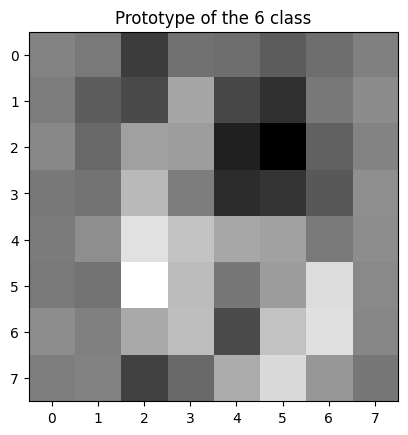

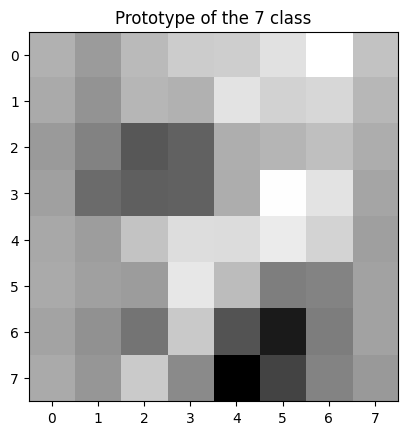

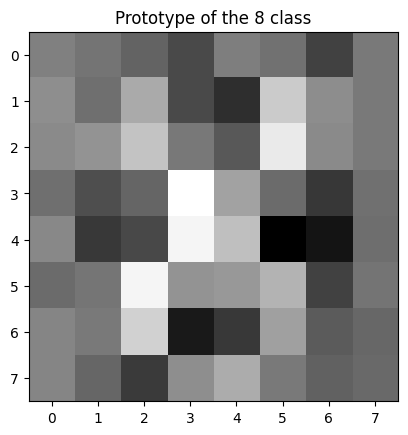

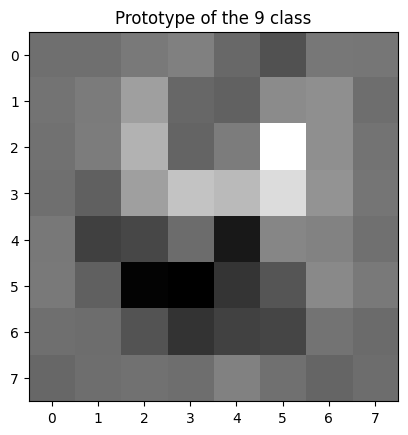

In [ ]:
#Extract the bias and weight from our model
learnt_bias = model.lin.bias.cpu().detach()
learnt_weights = model.lin.weight.cpu().detach()
print(f"Bias: {learnt_bias}")

#Print the state of the weights
for i in range(10):
  plt.imshow(learnt_weights[i].reshape((8, 8)), cmap="gray")
  plt.title(f"Prototype of the {i} class")
  plt.show()

However, the images are blurry does not indicate what each weight is doing.

### Exercise 2.2: T-SNE weight projection

Otherwise with more complex model we can still see the distribution of the classes as learnt by the model through some visualization techniques.

Let's try t-sne: it allows to project into low dimensional representation (e.g. 2D) data which lies in very high
dimensional spaces.


Let's try to projects the learnt weights into a 2D space.

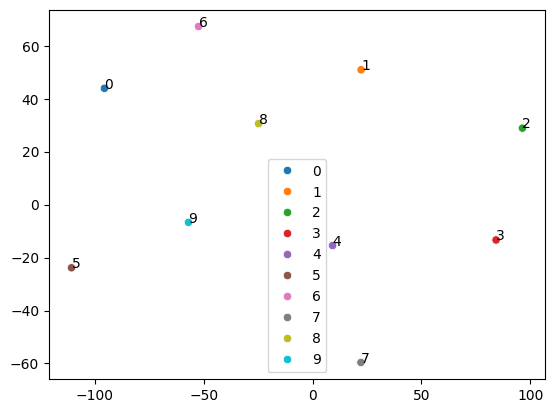

In [ ]:
import seaborn as sns
from sklearn.manifold import TSNE

# Il faut passer les poids du modèle (.lin.weight) convertis en numpy à fit_transform
# On a mis perplexity=5 car il y a peu de points (10 chiffres)
projected_weights = TSNE(n_components=2, init="pca", learning_rate='auto', perplexity=5).fit_transform(model.lin.weight.detach().cpu().numpy())

# Il faut générer une liste de labels de 0 à 9 pour la couleur (hue)
sns.scatterplot(x=projected_weights[:,0], y=projected_weights[:,1], hue=[str(i) for i in range(10)])

# Il faut fermer la boucle range(10) pour annoter les 10 points
[plt.text(projected_weights[i,0], projected_weights[i,1], s=str(i)) for i in range(10)]

plt.show()

Each point on this plot represents an **ideal feature** (or prototype) that the model has learned to recognize a specific digit.

If two points are **close to each other**, it implies that their **weight vectors are similar**. In other words, the model activates the same pixel areas to detect these two digits.

This plot demonstrates that our model has not simply memorized random pixels by rote. Instead, it has learned a semantic representation of the digits. It has 'understood' that the shape of a 3 is closer to that of an 8 than to that of a 1.

Technical Note: Since we used a perplexity of 5 (very low) due to the small number of data points (10), the exact layout may vary if the code is re-run.

Let's do it with the samples in the test set now.

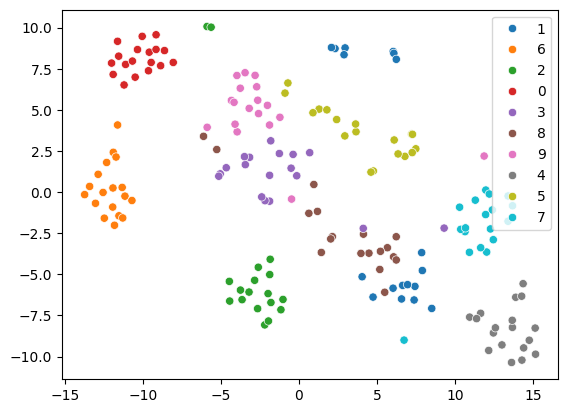

In [ ]:
# We apply TSNE on test samples
projected_samples = TSNE(n_components=2, init="pca", learning_rate='auto').fit_transform(x_test.cpu().numpy())

# Colorize point based on their class
sns.scatterplot(x=projected_samples[:,0], y=projected_samples[:,1], hue=[str(y_i.item()) for y_i in y_test])

plt.show()

What can we observe ?

1. Good Separation (High Accuracy) :


*   Observation: The points form distinct **clusters** of a single color.
*   That means that model learned to distinguish the digits. For example, all the "0s" (in red, top left) are tightly grouped together and far from the others. This confirms the model works well on data it has never seen before (generalization).
    

2. Semantic Proximity (Visual Similarity)

    Observation: Some clusters are very close or slightly touching, while others are far apart.

    Meaning: The model puts digits that "look alike" near each other.

        Example: The 9s (pink) and 3s (purple) are neighbors in the middle. This makes sense because both shapes have loops and curves.

        Contrast: The 0s (red) are far away from the 1s (blue), as a circle looks nothing like a straight line.

3. Some Errors

    Observation: We can see 2 green points on the top of the chart far from their cluster.

    Conclusion: The few points that are "lost" between clusters represent the hard-to-read digits where the model likely makes mistakes.

## SUMMARY

We now have a general data pipeline and training loop which you can use for training many
types of models using Pytorch.

torch.nn

*   Module : creates a callable which behaves like a function, but can also contain state(such as neural net layer weights). It knows what Parameter (s) it contains and can zero all their gradients, loop through them for weight updates, etc.

*   Parameter : a wrapper for a tensor that tells a Module that it has weights that need updating during backprop. Only tensors with the requires_grad attribute set are updated

*   Functional : a module(usually imported into the F namespace by convention) which contains activation functions, loss functions, etc, as well as non-stateful versions of layers such as convolutional and linear layers.


torch.optim : Contains optimizers such as SGD , which update the weights of
Parameter during the backward step

Dataset : An abstract interface of objects with a len and a getitem ,
including classes provided with Pytorch such as TensorDataset


DataLoader : Takes any Dataset and creates an iterator which returns batches of
data.

